In [1]:
!pip install xlrd -q

In [2]:
import pandas as pd

df = pd.read_excel('/content/default of credit card clients.xls', header=1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.shape

(30000, 25)

In [4]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [5]:
df = df.rename(columns={
    'default payment next month': 'default'
})

df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default']

In [6]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['default'].value_counts()

,count
default,
0,23364
1,6636


In [9]:
default_percentage = df['default'].value_counts(normalize=True) * 100

default_percentage

,proportion
default,
0,77.88
1,22.12


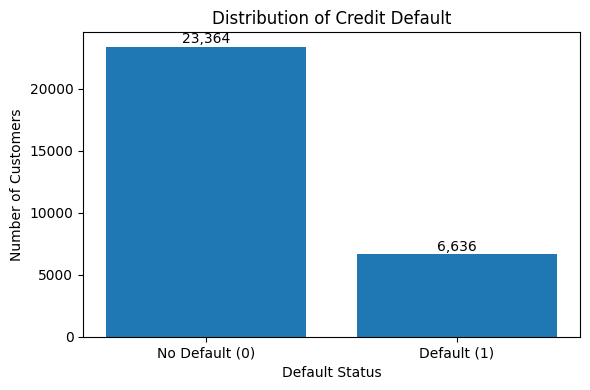

In [10]:
import matplotlib.pyplot as plt

default_counts = df['default'].value_counts().sort_index()

plt.figure(figsize=(6, 4))

bars = plt.bar(
    ['No Default (0)', 'Default (1)'],
    default_counts.values
)

plt.title('Distribution of Credit Default')
plt.xlabel('Default Status')
plt.ylabel('Number of Customers')

for bar, count in zip(bars, default_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{count:,}',
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    '/content/class_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

In [12]:
df[['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']].describe()

,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,5663.580500
std,129747.661567,9.217904,73635.860576,16563.280354
min,10000.000000,21.000000,-165580.000000,0.000000
25%,50000.000000,28.000000,3558.750000,1000.000000
50%,140000.000000,34.000000,22381.500000,2100.000000
75%,240000.000000,41.000000,67091.000000,5006.000000
max,1000000.000000,79.000000,964511.000000,873552.000000


In [13]:
print("SEX:", sorted(df['SEX'].unique()))
print("EDUCATION:", sorted(df['EDUCATION'].unique()))
print("MARRIAGE:", sorted(df['MARRIAGE'].unique()))

SEX: [np.int64(1), np.int64(2)]
EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [14]:
df['EDUCATION'] = df['EDUCATION'].replace({
    0: 4,
    5: 4,
    6: 4
})

df['MARRIAGE'] = df['MARRIAGE'].replace({
    0: 3
})

print("EDUCATION:", sorted(df['EDUCATION'].unique()))
print("MARRIAGE:", sorted(df['MARRIAGE'].unique()))

EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE: [np.int64(1), np.int64(2), np.int64(3)]


In [15]:
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_columns:
    print(col, sorted(df[col].unique()))

PAY_0 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [16]:
for col in pay_columns:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int6

In [17]:
# Create a separate copy for modelling
model_df = df.copy()

pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Convert non-positive repayment statuses to 0
for col in pay_columns:
    model_df[col] = model_df[col].apply(lambda x: 0 if x <= 0 else x)

# Check the cleaned values
for col in pay_columns:
    print(col, sorted(model_df[col].unique()))

PAY_0 [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [18]:
pay0_default_rate = (
    model_df.groupby('PAY_0')['default']
    .agg(['count', 'mean'])
    .reset_index()
)

pay0_default_rate['default_rate_%'] = (
    pay0_default_rate['mean'] * 100
).round(2)

pay0_default_rate[['PAY_0', 'count', 'default_rate_%']]

,PAY_0,count,default_rate_%
0,0,23182,13.83
1,1,3688,33.95
2,2,2667,69.14
3,3,322,75.78
4,4,76,68.42
5,5,26,50.00
6,6,11,54.55
7,7,9,77.78
8,8,19,57.89


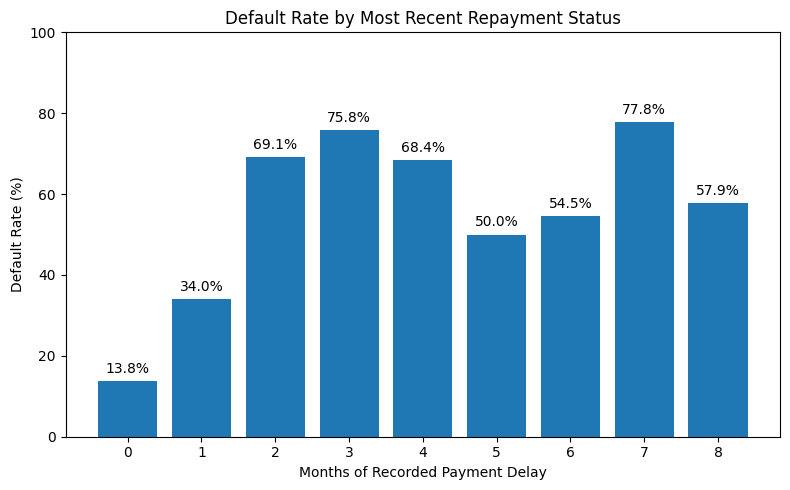

In [19]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    pay0_default_rate['PAY_0'].astype(str),
    pay0_default_rate['default_rate_%']
)

plt.title('Default Rate by Most Recent Repayment Status')
plt.xlabel('Months of Recorded Payment Delay')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 100)

for bar, rate in zip(bars, pay0_default_rate['default_rate_%']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{rate:.1f}%',
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    '/content/default_rate_by_repayment_status.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [20]:
# -----------------------------
# CREDIT RISK BUSINESS ANALYSIS
# -----------------------------

# 1. Credit limit vs default
credit_summary = (
    model_df.groupby('default')['LIMIT_BAL']
    .agg(['count', 'mean', 'median'])
    .round(2)
)

print("CREDIT LIMIT BY DEFAULT STATUS")
display(credit_summary)


# 2. Age vs default
age_summary = (
    model_df.groupby('default')['AGE']
    .agg(['mean', 'median'])
    .round(2)
)

print("\nAGE BY DEFAULT STATUS")
display(age_summary)


# 3. Most recent bill amount vs default
bill_summary = (
    model_df.groupby('default')['BILL_AMT1']
    .agg(['mean', 'median'])
    .round(2)
)

print("\nRECENT BILL AMOUNT BY DEFAULT STATUS")
display(bill_summary)


# 4. Most recent payment amount vs default
payment_summary = (
    model_df.groupby('default')['PAY_AMT1']
    .agg(['mean', 'median'])
    .round(2)
)

print("\nRECENT PAYMENT AMOUNT BY DEFAULT STATUS")
display(payment_summary)


# 5. Credit limit bands
model_df['credit_limit_band'] = pd.cut(
    model_df['LIMIT_BAL'],
    bins=[0, 50000, 100000, 200000, 500000, float('inf')],
    labels=[
        '≤50K',
        '50K–100K',
        '100K–200K',
        '200K–500K',
        '>500K'
    ]
)

credit_band_default = (
    model_df.groupby(
        'credit_limit_band',
        observed=False
    )['default']
    .agg(['count', 'mean'])
    .reset_index()
)

credit_band_default['default_rate_%'] = (
    credit_band_default['mean'] * 100
).round(2)

print("\nDEFAULT RATE BY CREDIT LIMIT BAND")
display(
    credit_band_default[
        ['credit_limit_band', 'count', 'default_rate_%']
    ]
)

CREDIT LIMIT BY DEFAULT STATUS


,count,mean,median
default,,,
0,23364,178099.73,150000.0
1,6636,130109.66,90000.0



AGE BY DEFAULT STATUS


,mean,median
default,,
0,35.42,34.0
1,35.73,34.0



RECENT BILL AMOUNT BY DEFAULT STATUS


,mean,median
default,,
0,51994.23,23119.5
1,48509.16,20185.0



RECENT PAYMENT AMOUNT BY DEFAULT STATUS


,mean,median
default,,
0,6307.34,2459.5
1,3397.04,1636.0



DEFAULT RATE BY CREDIT LIMIT BAND


,credit_limit_band,count,default_rate_%
0,≤50K,7676,31.79
1,50K–100K,4822,25.80
2,100K–200K,7880,19.48
3,200K–500K,9416,14.80
4,>500K,206,11.17


In [21]:
# --------------------------------
# MODEL PREPARATION
# --------------------------------

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Remove fields that should not be used as predictors
X = model_df.drop(
    columns=['ID', 'default', 'credit_limit_band']
)

y = model_df['default']

# Categorical variables
categorical_features = [
    'SEX',
    'EDUCATION',
    'MARRIAGE'
]

# Everything else is numerical
numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# 80% training / 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])
print("Training default rate:", round(y_train.mean() * 100, 2), "%")
print("Testing default rate:", round(y_test.mean() * 100, 2), "%")

Training records: 24000
Testing records: 6000
Training default rate: 22.12 %
Testing default rate: 22.12 %


In [22]:
# --------------------------------
# TRAIN MODELS
# --------------------------------

# Baseline model
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

# Logistic Regression
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Decision Tree
tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)
logistic_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


In [23]:
# --------------------------------
# MODEL EVALUATION
# --------------------------------

models = {
    'Baseline': baseline_model,
    'Logistic Regression': logistic_model,
    'Decision Tree': tree_model
}

results = []

for name, model in models.items():

    predictions = model.predict(X_test)

    if hasattr(model.named_steps['classifier'], 'predict_proba'):
        probabilities = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, probabilities)
    else:
        auc = None

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'F1 Score': f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'ROC-AUC': auc
    })

results_df = pd.DataFrame(results)

results_df[['Accuracy',
            'Precision',
            'Recall',
            'F1 Score',
            'ROC-AUC']] = (
    results_df[
        ['Accuracy',
         'Precision',
         'Recall',
         'F1 Score',
         'ROC-AUC']
    ] * 100
).round(2)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,77.88,0.00,0.00,0.00,50.00
1,Logistic Regression,77.53,49.29,54.56,51.79,74.60
2,Decision Tree,76.75,47.82,56.14,51.65,75.92


In [24]:
# --------------------------------
# MODEL EVALUATION
# --------------------------------

models = {
    'Baseline': baseline_model,
    'Logistic Regression': logistic_model,
    'Decision Tree': tree_model
}

results = []

for name, model in models.items():

    predictions = model.predict(X_test)

    if hasattr(model.named_steps['classifier'], 'predict_proba'):
        probabilities = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, probabilities)
    else:
        auc = None

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'F1 Score': f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'ROC-AUC': auc
    })

results_df = pd.DataFrame(results)

results_df[['Accuracy',
            'Precision',
            'Recall',
            'F1 Score',
            'ROC-AUC']] = (
    results_df[
        ['Accuracy',
         'Precision',
         'Recall',
         'F1 Score',
         'ROC-AUC']
    ] * 100
).round(2)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,77.88,0.00,0.00,0.00,50.00
1,Logistic Regression,77.53,49.29,54.56,51.79,74.60
2,Decision Tree,76.75,47.82,56.14,51.65,75.92


In [25]:
# --------------------------------
# CONFUSION MATRIX RESULTS
# --------------------------------

from sklearn.metrics import confusion_matrix

for name, model in {
    'Logistic Regression': logistic_model,
    'Decision Tree': tree_model
}.items():

    predictions = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    print(f"\n{name}")
    print("-" * 35)
    print("True Negatives:", tn)
    print("False Positives:", fp)
    print("False Negatives:", fn)
    print("True Positives:", tp)
    print("Actual Defaulters:", tp + fn)
    print(
        "Defaults Identified:",
        f"{tp} of {tp + fn}"
    )


Logistic Regression
-----------------------------------
True Negatives: 3928
False Positives: 745
False Negatives: 603
True Positives: 724
Actual Defaulters: 1327
Defaults Identified: 724 of 1327

Decision Tree
-----------------------------------
True Negatives: 3860
False Positives: 813
False Negatives: 582
True Positives: 745
Actual Defaulters: 1327
Defaults Identified: 745 of 1327


In [26]:
# --------------------------------
# HIGH-RISK CUSTOMER CAPTURE
# --------------------------------

# Get predicted default probabilities
tree_probabilities = tree_model.predict_proba(
    X_test
)[:, 1]

risk_results = pd.DataFrame({
    'actual_default': y_test.values,
    'predicted_risk': tree_probabilities
})

# Sort customers from highest predicted risk to lowest
risk_results = risk_results.sort_values(
    'predicted_risk',
    ascending=False
).reset_index(drop=True)

# Top 20% highest-risk customers
top_20_n = int(len(risk_results) * 0.20)

top_20 = risk_results.head(top_20_n)

total_defaults = risk_results[
    'actual_default'
].sum()

defaults_in_top_20 = top_20[
    'actual_default'
].sum()

capture_rate = (
    defaults_in_top_20 / total_defaults
) * 100

print("Test customers:", len(risk_results))
print("Actual defaults:", total_defaults)
print("Top 20% high-risk customers:", top_20_n)
print("Defaults found in top 20%:", defaults_in_top_20)
print(
    "Default capture rate:",
    round(capture_rate, 2),
    "%"
)

Test customers: 6000
Actual defaults: 1327
Top 20% high-risk customers: 1200
Defaults found in top 20%: 651
Default capture rate: 49.06 %


<Figure size 600x500 with 0 Axes>

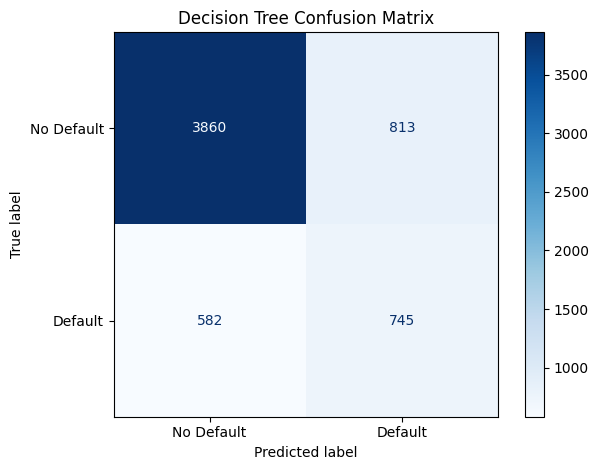

<Figure size 700x500 with 0 Axes>

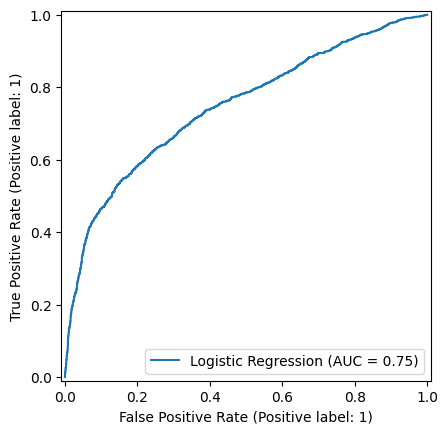

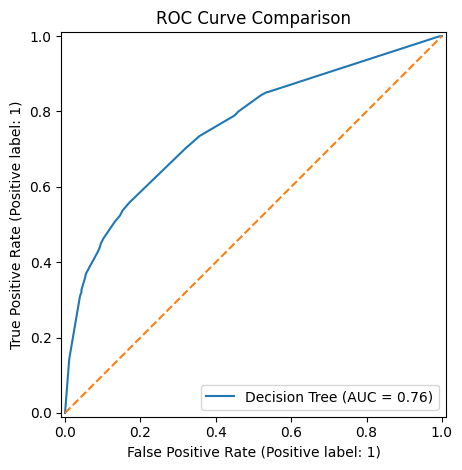

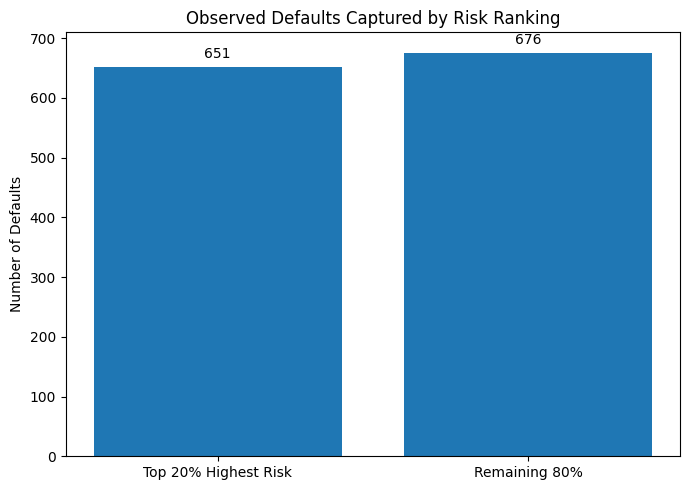

In [27]:
# --------------------------------
# FINAL MODEL VISUALIZATIONS
# --------------------------------

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Decision Tree predictions
tree_predictions = tree_model.predict(X_test)

# 1. Confusion Matrix
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_predictions,
    display_labels=['No Default', 'Default'],
    cmap='Blues'
)

plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.savefig(
    '/content/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# 2. ROC Curve comparison
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test,
    name='Logistic Regression'
)

RocCurveDisplay.from_estimator(
    tree_model,
    X_test,
    y_test,
    name='Decision Tree'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title('ROC Curve Comparison')
plt.tight_layout()
plt.savefig(
    '/content/roc_curve.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# 3. High-risk capture visualization
risk_capture = pd.DataFrame({
    'Customer Group': [
        'Top 20% Highest Risk',
        'Remaining 80%'
    ],
    'Defaults': [
        defaults_in_top_20,
        total_defaults - defaults_in_top_20
    ]
})

plt.figure(figsize=(7, 5))

bars = plt.bar(
    risk_capture['Customer Group'],
    risk_capture['Defaults']
)

plt.title('Observed Defaults Captured by Risk Ranking')
plt.ylabel('Number of Defaults')

for bar, value in zip(bars, risk_capture['Defaults']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 15,
        f'{int(value):,}',
        ha='center'
    )

plt.tight_layout()
plt.savefig(
    '/content/risk_capture.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [30]:
# --------------------------------
# CREATE SQL DATABASE
# --------------------------------

import sqlite3

# Create a copy specifically for SQL
sql_df = model_df.copy()

# Rename target column because "default" can conflict with SQL syntax
sql_df = sql_df.rename(columns={
    'default': 'default_flag'
})

sql_df['credit_limit_band'] = (
    sql_df['credit_limit_band'].astype(str)
)

# Create SQLite database
conn = sqlite3.connect('/content/credit_risk.db')

# Load dataframe into SQL table
sql_df.to_sql(
    'credit_customers',
    conn,
    if_exists='replace',
    index=False
)

print("SQL database created successfully.")

# Verify
pd.read_sql("""
SELECT COUNT(*) AS total_customers
FROM credit_customers;
""", conn)

SQL database created successfully.


,total_customers
0,30000


In [31]:
# --------------------------------
# SQL BUSINESS ANALYSIS
# --------------------------------

# 1. Portfolio KPIs
query_1 = """
SELECT
    COUNT(*) AS total_customers,
    SUM(default_flag) AS total_defaults,
    ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct,
    ROUND(AVG(LIMIT_BAL), 2) AS avg_credit_limit,
    ROUND(AVG(PAY_AMT1), 2) AS avg_recent_payment
FROM credit_customers;
"""

print("PORTFOLIO KPIs")
display(pd.read_sql(query_1, conn))


# 2. Default rate by credit limit band
query_2 = """
SELECT
    credit_limit_band,
    COUNT(*) AS customers,
    SUM(default_flag) AS defaults,
    ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct
FROM credit_customers
GROUP BY credit_limit_band
ORDER BY default_rate_pct DESC;
"""

print("\nDEFAULT RATE BY CREDIT LIMIT BAND")
display(pd.read_sql(query_2, conn))


# 3. Default risk by repayment delay
query_3 = """
SELECT
    PAY_0 AS repayment_delay_months,
    COUNT(*) AS customers,
    SUM(default_flag) AS defaults,
    ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct
FROM credit_customers
GROUP BY PAY_0
ORDER BY PAY_0;
"""

print("\nDEFAULT RATE BY REPAYMENT STATUS")
display(pd.read_sql(query_3, conn))


# 4. Financial behaviour by default status
query_4 = """
SELECT
    default_flag,
    COUNT(*) AS customers,
    ROUND(AVG(LIMIT_BAL), 2) AS avg_credit_limit,
    ROUND(AVG(BILL_AMT1), 2) AS avg_recent_bill,
    ROUND(AVG(PAY_AMT1), 2) AS avg_recent_payment
FROM credit_customers
GROUP BY default_flag;
"""

print("\nFINANCIAL BEHAVIOUR BY DEFAULT STATUS")
display(pd.read_sql(query_4, conn))

PORTFOLIO KPIs


,total_customers,total_defaults,default_rate_pct,avg_credit_limit,avg_recent_payment
0,30000,6636,22.12,167484.32,5663.58



DEFAULT RATE BY CREDIT LIMIT BAND


,credit_limit_band,customers,defaults,default_rate_pct
0,≤50K,7676,2440,31.79
1,50K–100K,4822,1244,25.80
2,100K–200K,7880,1535,19.48
3,200K–500K,9416,1394,14.80
4,>500K,206,23,11.17



DEFAULT RATE BY REPAYMENT STATUS


,repayment_delay_months,customers,defaults,default_rate_pct
0,0,23182,3207,13.83
1,1,3688,1252,33.95
2,2,2667,1844,69.14
3,3,322,244,75.78
4,4,76,52,68.42
5,5,26,13,50.00
6,6,11,6,54.55
7,7,9,7,77.78
8,8,19,11,57.89



FINANCIAL BEHAVIOUR BY DEFAULT STATUS


,default_flag,customers,avg_credit_limit,avg_recent_bill,avg_recent_payment
0,0,23364,178099.73,51994.23,6307.34
1,1,6636,130109.66,48509.16,3397.04


In [32]:
# --------------------------------
# SAVE SQL ANALYSIS FILE
# --------------------------------

sql_script = """
-- Credit Risk Analysis
-- Dataset: UCI Default of Credit Card Clients
-- Records analyzed: 30,000


-- 1. Portfolio-level KPIs
SELECT
    COUNT(*) AS total_customers,
    SUM(default_flag) AS total_defaults,
    ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct,
    ROUND(AVG(LIMIT_BAL), 2) AS avg_credit_limit,
    ROUND(AVG(PAY_AMT1), 2) AS avg_recent_payment
FROM credit_customers;


-- 2. Default rate by credit limit band
SELECT
    credit_limit_band,
    COUNT(*) AS customers,
    SUM(default_flag) AS defaults,
    ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct
FROM credit_customers
GROUP BY credit_limit_band
ORDER BY default_rate_pct DESC;


-- 3. Default risk by repayment delay
SELECT
    PAY_0 AS repayment_delay_months,
    COUNT(*) AS customers,
    SUM(default_flag) AS defaults,
    ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct
FROM credit_customers
GROUP BY PAY_0
ORDER BY PAY_0;


-- 4. Financial behaviour by default status
SELECT
    default_flag,
    COUNT(*) AS customers,
    ROUND(AVG(LIMIT_BAL), 2) AS avg_credit_limit,
    ROUND(AVG(BILL_AMT1), 2) AS avg_recent_bill,
    ROUND(AVG(PAY_AMT1), 2) AS avg_recent_payment
FROM credit_customers
GROUP BY default_flag;
"""

with open('/content/credit_risk_analysis.sql', 'w') as file:
    file.write(sql_script)

print("credit_risk_analysis.sql created successfully.")

credit_risk_analysis.sql created successfully.


In [33]:
# --------------------------------
# CUSTOMER RISK SEGMENTATION
# --------------------------------

risk_report = model_df.loc[
    X_test.index,
    ['ID', 'LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1']
].copy()

risk_report['actual_default'] = y_test.values
risk_report['predicted_default_probability'] = tree_probabilities

# Divide customers into 5 equal risk groups
risk_report['risk_segment'] = pd.qcut(
    risk_report['predicted_default_probability'].rank(method='first'),
    q=5,
    labels=[
        'Low',
        'Moderate',
        'Elevated',
        'High',
        'Very High'
    ]
)

# Summary of each segment
risk_segment_summary = (
    risk_report.groupby(
        'risk_segment',
        observed=False
    )
    .agg(
        customers=('ID', 'count'),
        actual_defaults=('actual_default', 'sum'),
        average_predicted_risk=(
            'predicted_default_probability',
            'mean'
        ),
        actual_default_rate=(
            'actual_default',
            'mean'
        )
    )
    .reset_index()
)

risk_segment_summary[
    'average_predicted_risk'
] = (
    risk_segment_summary[
        'average_predicted_risk'
    ] * 100
).round(2)

risk_segment_summary[
    'actual_default_rate'
] = (
    risk_segment_summary[
        'actual_default_rate'
    ] * 100
).round(2)

display(risk_segment_summary)

,risk_segment,customers,actual_defaults,average_predicted_risk,actual_default_rate
0,Low,1200,101,22.93,8.42
1,Moderate,1200,101,25.53,8.42
2,Elevated,1200,200,37.82,16.67
3,High,1200,275,50.29,22.92
4,Very High,1200,650,80.40,54.17


In [34]:
# Save detailed customer-level risk output
risk_report.to_csv(
    '/content/customer_risk_report.csv',
    index=False
)

# Save model comparison results
results_df.to_csv(
    '/content/model_comparison.csv',
    index=False
)

print("customer_risk_report.csv created.")
print("model_comparison.csv created.")

customer_risk_report.csv created.
model_comparison.csv created.
